<a href="https://colab.research.google.com/github/Emmanuel-Yerbo/GIS/blob/main/Python%20for%20Urban%20Analysis/Setup/chapter1_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setting Up: Open Street Map as a Data Source

In [1]:
!pip install -q osmnx geopandas contextily folium mapclassify momepy networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.4 MB/s eta 0:00:00


In [2]:
# Verifying if the environment is working


In [3]:
import sys
import warnings
warnings.filterwarnings("ignore")

In [4]:
print("="*65)
print(" chapter 1- Environment Set and checks")
print("="*65)

 chapter 1- Environment Set and checks


In [5]:
packages = {
    "osmnx":None, "geopandas":None, 'pandas':None,
    "numpy":None, "matplotlib":None, "contextily":None,
    "networkx":None, "shapely":None, "folium":None,
    "mapclassify":None
}

for pkg in packages:
  try:
    mod = __import__(pkg)
    packages[pkg] = mod.__version__
    print(f"Correct {pkg:20s} verson{mod.__version__}")
  except ImportError:
    print(f"Wrong {pkg:20s} - Not Installed")
missing = [k for k, v in packages.items() if v is None]
if missing:
  print(f"\n Missing Packages: {":, ".join(missing)}")
  print(" Run the install cell above!")
else:
  print("\n All packages installed sucessfully!")

Correct osmnx                verson2.1.0
Correct geopandas            verson1.1.3
Correct pandas               verson2.2.2
Correct numpy                verson2.0.2
Correct matplotlib           verson3.10.0
Correct contextily           verson1.7.1
Correct networkx             verson3.6.1
Correct shapely              verson2.1.2
Correct folium               verson0.20.0
Correct mapclassify          verson2.10.0

 All packages installed sucessfully!


## The configuration
- Study Area
- Study Region
- CRS UTM Accra
- CRS WEB Mercator

In [6]:
import os
from pathlib import Path

In [7]:
# Study Area (Accra)
study_area = "Accra, Ghana"
study_region = "Greater Accra Region, Ghana"

#CRS
crs_wgs84 = "EPSG:4326"
crs_mercator = "EPSG:3857"
crs_utm_accra = "EPSG:32630"

In [8]:
# Project Folders
Data_Dir = Path("data")
output_Dir = Path("outputs")
feature_Dir = Path(output_Dir/'figures')

In [9]:
for d in [Data_Dir, output_Dir, feature_Dir]:
  d.mkdir(parents=True, exist_ok =True)

In [10]:
# Visualization Defaults
dark_bd = "#0e1117"
accent_cmap = "YlOrRd"
amenity_color  = "#00e5ff"


In [11]:
print(f"Study Area -> {study_area}")
print(f"Data Dir -> {Data_Dir}")
print(f"Output -> {output_Dir}")

Study Area -> Accra, Ghana
Data Dir -> data
Output -> outputs


### Study Area Pattern
1. Define a place name (string -> "Accra, Ghana")
2. Nomatim resolves it -> Administrative Polygon
3. Every chapter clipts it -> Consistent spatial extent


### How OSM works
- Nodes--- Single points (lat, lon)
- Ways --- Ordered lists of nodes (roads, buildings outlines)
- Relations --- groups of ways or nodes

Each element carries a tags- key->value pairs like amenity=hospital or building = residential.

It is how we query osm data based on their tags

In [12]:
import osmnx as ox
import geopandas as gpd

In [13]:
# Study area
study_gdf = ox.geocode_to_gdf(study_area)

In [14]:
print(f"Study area: {study_area}")
print(f"CRS : {study_gdf.crs}")
print(f"Geometry type: {study_gdf.geometry.iloc[0].geom_type}")
print(f"Bounding box: {study_gdf.total_bounds}")

Study area: Accra, Ghana
CRS : epsg:4326
Geometry type: Polygon
Bounding box: [-0.2842713  5.5169264 -0.0548565  5.6673682]


In [15]:
# Geodataframe
# Always compare and compute area in projected CRS

In [16]:
print("---Boundary Attributes ---")
print(study_gdf[['display_name', 'type', 'geometry']].to_string())

---Boundary Attributes ---
                                                           display_name            type                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [17]:
# Total Area in Meters
area_m2 = study_gdf.to_crs(crs_utm_accra).area.iloc[0]
area_km2 = area_m2 / 1e6
print(f"\n Area = {area_km2:.2f} km²")


 Area = 228.94 km²


### Saving it as a Geopackage
Why Geopackage
1. Single file
2. Long column support
3. Stores crs metadata properly
4. OGC

In [18]:
boundary = Data_Dir / "study_area_boundary.gpkg"
study_gdf.to_file(boundary, driver = "GPKG")
print(f"Boundar saved -> {boundary}")

Boundar saved -> data/study_area_boundary.gpkg


### Visualization
Context requires data in the EPSG;3857 Web Mercator (same projection as google maps, osm and all web tiles)

In [19]:
import matplotlib.pyplot as plt
import contextily as cx

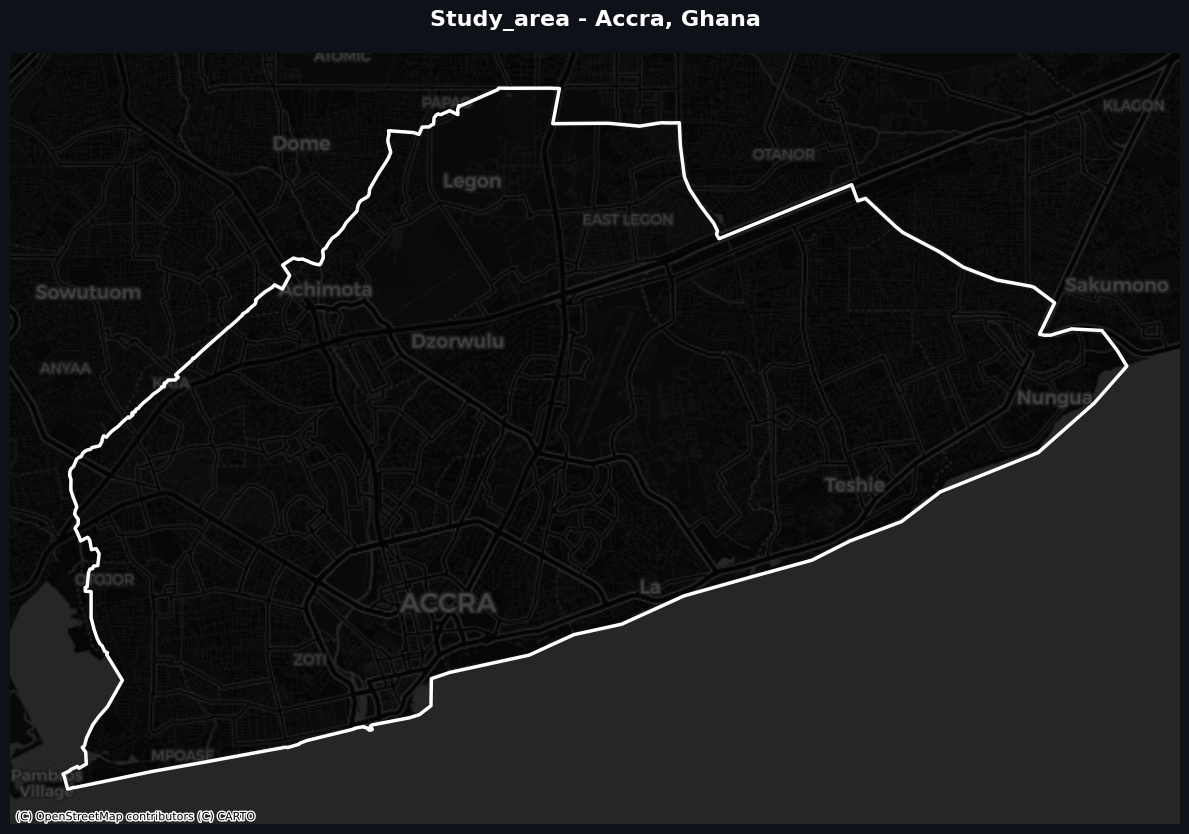

In [20]:
fig, ax = plt.subplots(1,1, figsize = (12, 12))
fig.patch.set_facecolor(dark_bd)
ax.set_facecolor(dark_bd)

# Boundary Plot
study_gdf.to_crs(crs_mercator).plot(
    ax = ax,
    facecolor = 'none',
    edgecolor="#ffffff",
    linewidth= 2.5
)

# adding a web map
cx.add_basemap(ax, source = cx.providers.CartoDB.DarkMatter)
ax.set_axis_off()
ax.set_title(
    f"Study_area - {study_area}",
    fontsize = 16, fontweight = 'bold',
    color =  'white', pad = 20
)

fig.tight_layout()
fig.savefig(feature_Dir / 'ch1_boundary.png', dpi = 150,
            bbox_inches = 'tight', facecolor = dark_bd)
plt.show()

In [21]:
# Interactive Map with Folium
import folium
centroid = study_gdf.geometry.iloc[0].centroid

m = folium.Map(
    location = [centroid.y, centroid.x],
    zoom_start = 12,
    tiles = "CartoDB dark_matter"
)

# Boundary Overylay
folium.GeoJson(
    study_gdf.to_json(),
    style_function=lambda x:{
        'fillColor':'transparent',
        'color':"#00e5ff",
        'weight':3
    },
    tooltip=study_area,
).add_to(m)

m.save(str(output_Dir / "chi_study_interactive.html"))
m